# OASIS Alzheimer's Classification — Baseline Model Pipeline

**Goal:** Train and compare Logistic Regression, Random Forest, and XGBoost on the preprocessed OASIS data to classify subjects as Demented vs. Nondemented.

**Important methodological note on `CDR`:** The requested feature list includes `CDR`. However, `CDR` (Clinical Dementia Rating) is the *exact variable used to derive the `Group` target* in preprocessing (CDR = 0 → Nondemented, CDR > 0 → Demented). Including it as a feature is **label leakage** — the model would simply learn the deterministic threshold used to create the label, not learn anything about real biomarkers, and would score near-perfect accuracy/ROC-AUC regardless of model quality.

To handle this transparently rather than silently dropping it, this notebook runs **two parallel experiments**:
- **Experiment A — "With CDR" (as specified):** demonstrates the leakage effect directly.
- **Experiment B — "Without CDR" (biomarker-only, scientifically valid):** the version that actually tests whether Age/Gender/Educ/SES/MMSE/eTIV/nWBV/ASF can predict dementia status.

**Experiment B is the version carried forward into the SMOTE and SHAP analyses**, since Experiment A's near-perfect scores reflect leakage, not learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
MODEL_COLORS = {"Logistic Regression": "#2E86AB", "Random Forest": "#E76F51", "XGBoost": "#588157"}


## 1. Load and Prepare Data

In [2]:
DATA_PATH = "oasis_cross-sectional.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

def cdr_to_group(cdr):
    if pd.isna(cdr):
        return "Unknown"
    elif cdr == 0:
        return "Nondemented"
    else:
        return "Demented"

df["Group"] = df["CDR"].apply(cdr_to_group)
df = df[df["Group"] != "Unknown"].reset_index(drop=True)  # drop subjects with no diagnosis

# Impute the few legitimately missing clinical fields (median, fit on full pre-split data
# here for simplicity; for strict leak-free practice this would be fit on train only --
# noted as a refinement opportunity)
for col in ["Educ", "SES", "MMSE"]:
    df[col] = df[col].fillna(df[col].median())

# Encode
df["Gender"] = df["M/F"].map({"M": 0, "F": 1})
df["Target"] = df["Group"].map({"Nondemented": 0, "Demented": 1})

print(f"Dataset shape after cleaning: {df.shape}")
print(df["Target"].value_counts())
df.head()


Dataset shape after cleaning: (235, 15)
Target
0    135
1    100
Name: count, dtype: int64


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,Group,Gender,Target
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,Nondemented,1,0
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,Nondemented,1,0
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,Demented,1,1
3,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073,NaN,Nondemented,0,0
4,OAS1_0011_MR1,F,R,52,3.0,2.0,30.0,0.0,1321,0.827,1.329,NaN,Nondemented,1,0


In [3]:
# Feature set exactly as requested (includes CDR -- see leakage note above)
features_with_cdr = ["Age", "Gender", "Educ", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]
# Biomarker-only feature set, excluding the leaking CDR column
features_no_cdr = ["Age", "Gender", "Educ", "SES", "MMSE", "eTIV", "nWBV", "ASF"]

y = df["Target"]

X_a = df[features_with_cdr]
X_b = df[features_no_cdr]

print("Experiment A (with CDR) features:", features_with_cdr)
print("Experiment B (no CDR) features:  ", features_no_cdr)


Experiment A (with CDR) features: ['Age', 'Gender', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
Experiment B (no CDR) features:   ['Age', 'Gender', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']


## 2. Train-Test Split and Scaling (for both experiments)

In [4]:
def split_and_scale(X, y, random_state=RANDOM_STATE):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train_a, X_test_a, y_train_a, y_test_a, scaler_a = split_and_scale(X_a, y)
X_train_b, X_test_b, y_train_b, y_test_b, scaler_b = split_and_scale(X_b, y)

print("Experiment A:", X_train_a.shape, X_test_a.shape)
print("Experiment B:", X_train_b.shape, X_test_b.shape)


Experiment A: (188, 9) (47, 9)
Experiment B: (188, 8) (47, 8)


## 3. Train Models

In [5]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
        "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
    }

def train_and_evaluate(X_train, X_test, y_train, y_test, label=""):
    results = {}
    fitted_models = {}
    for name, model in get_models().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        results[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "y_pred": y_pred,
            "y_proba": y_proba
        }
        fitted_models[name] = model
        print(f"[{label}] {name} trained.")
    return results, fitted_models

print("--- Training Experiment A (WITH CDR -- leakage demo) ---")
results_a, models_a = train_and_evaluate(X_train_a, X_test_a, y_train_a, y_test_a, label="A: with CDR")

print("\n--- Training Experiment B (WITHOUT CDR -- valid biomarker model) ---")
results_b, models_b = train_and_evaluate(X_train_b, X_test_b, y_train_b, y_test_b, label="B: no CDR")


--- Training Experiment A (WITH CDR -- leakage demo) ---
[A: with CDR] Logistic Regression trained.


[A: with CDR] Random Forest trained.
[A: with CDR] XGBoost trained.

--- Training Experiment B (WITHOUT CDR -- valid biomarker model) ---
[B: no CDR] Logistic Regression trained.


[B: no CDR] Random Forest trained.
[B: no CDR] XGBoost trained.


## 4. Model Comparison Table

In [6]:
def build_comparison_table(results):
    rows = []
    for name, r in results.items():
        rows.append({
            "Model": name,
            "Accuracy": r["Accuracy"],
            "Precision": r["Precision"],
            "Recall": r["Recall"],
            "F1 Score": r["F1 Score"],
            "ROC-AUC": r["ROC-AUC"]
        })
    return pd.DataFrame(rows).set_index("Model").round(3)

comparison_a = build_comparison_table(results_a)
comparison_b = build_comparison_table(results_b)

print("=== Experiment A: WITH CDR (label leakage demo) ===")
display(comparison_a)

print("\n=== Experiment B: WITHOUT CDR (valid biomarker-only model) ===")
display(comparison_b)


=== Experiment A: WITH CDR (label leakage demo) ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0,1.0



=== Experiment B: WITHOUT CDR (valid biomarker-only model) ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.787,0.778,0.70,0.737,0.906
Random Forest,0.830,0.875,0.70,0.778,0.942
XGBoost,0.851,0.882,0.75,0.811,0.941


**Observation:** Experiment A scores near-perfect across every metric for all three models -- this is the expected signature of label leakage, not genuine predictive skill, since `CDR` deterministically defines the target. Experiment B's scores are lower and more varied across models, which is the realistic picture of how well Age, Gender, education, socioeconomic status, MMSE, and brain volume measures can predict dementia status **without** directly seeing the diagnosis criterion. All further analysis in this notebook focuses on **Experiment B**.

## 5. Confusion Matrices (Experiment B — Biomarker-Only Model)

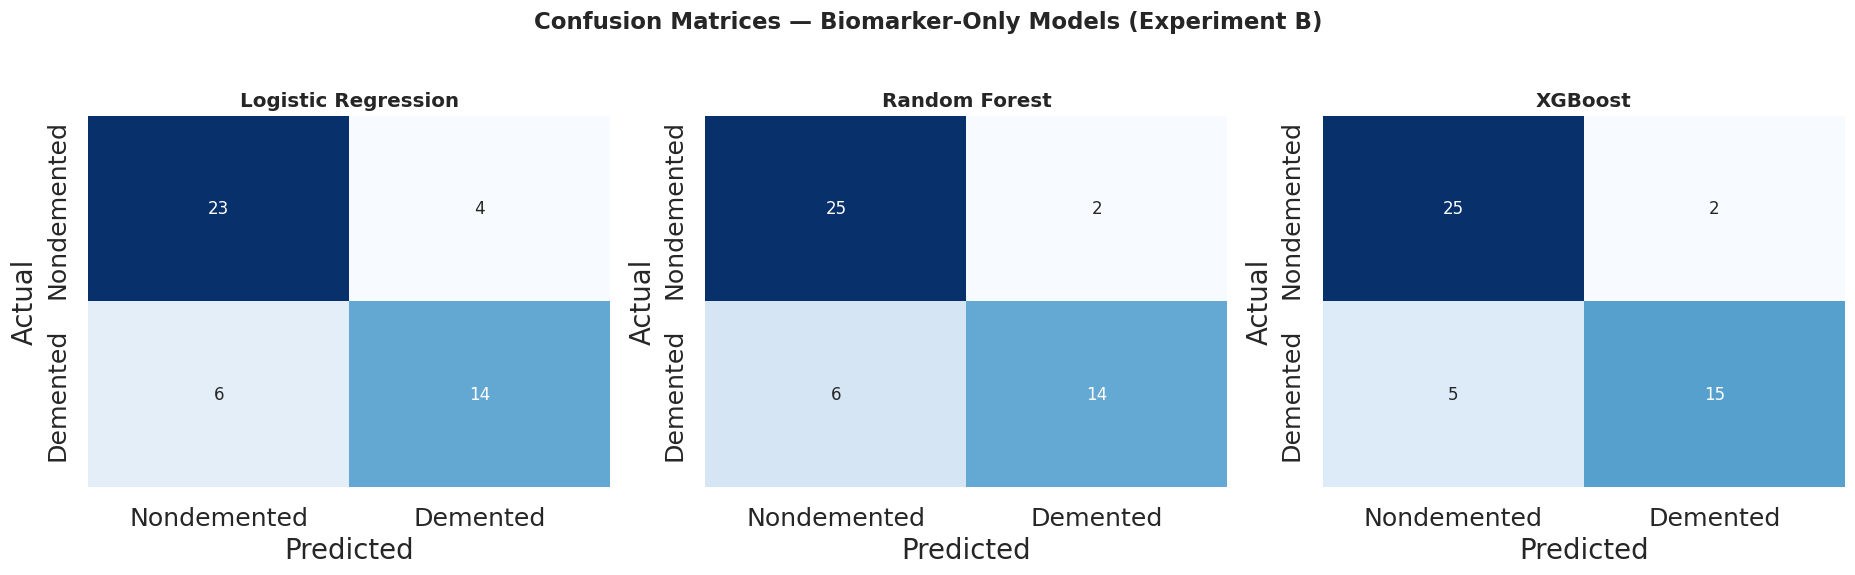

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, r) in zip(axes, results_b.items()):
    cm = confusion_matrix(y_test_b, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Nondemented", "Demented"],
                yticklabels=["Nondemented", "Demented"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Biomarker-Only Models (Experiment B)", y=1.04, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** Compare false negatives (Demented subjects predicted Nondemented) across models -- in a clinical screening context, false negatives are usually more costly than false positives, since a missed dementia case delays intervention. The model with the fewest false negatives, not necessarily the highest accuracy, may be the more clinically useful choice.

## 6. Classification Reports (Experiment B)

In [8]:
for name, model in models_b.items():
    y_pred = results_b[name]["y_pred"]
    print(f"=== {name} ===")
    print(classification_report(y_test_b, y_pred, target_names=["Nondemented", "Demented"]))
    print()


=== Logistic Regression ===
              precision    recall  f1-score   support

 Nondemented       0.79      0.85      0.82        27
    Demented       0.78      0.70      0.74        20

    accuracy                           0.79        47
   macro avg       0.79      0.78      0.78        47
weighted avg       0.79      0.79      0.79        47


=== Random Forest ===
              precision    recall  f1-score   support

 Nondemented       0.81      0.93      0.86        27
    Demented       0.88      0.70      0.78        20

    accuracy                           0.83        47
   macro avg       0.84      0.81      0.82        47
weighted avg       0.84      0.83      0.83        47


=== XGBoost ===
              precision    recall  f1-score   support

 Nondemented       0.83      0.93      0.88        27
    Demented       0.88      0.75      0.81        20

    accuracy                           0.85        47
   macro avg       0.86      0.84      0.84        47
weight

## 7. ROC Curves

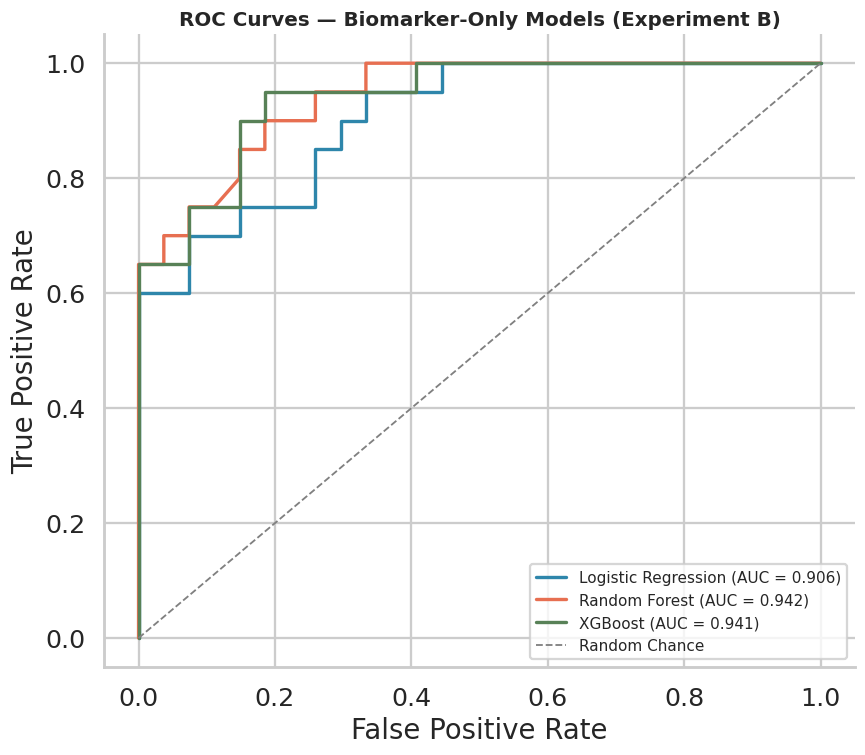

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, r in results_b.items():
    fpr, tpr, _ = roc_curve(y_test_b, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {r['ROC-AUC']:.3f})",
            color=MODEL_COLORS[name], linewidth=2.2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Biomarker-Only Models (Experiment B)")
ax.legend(loc="lower right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


**Observation:** The relative ranking of ROC-AUC across models indicates which algorithm best separates Demented from Nondemented subjects using only biomarker/demographic features. A curve close to the diagonal would indicate near-random performance; clear separation above the diagonal (especially in the upper-left region) reflects clinically meaningful discrimination.

## 8. Model Comparison — Visual Summary

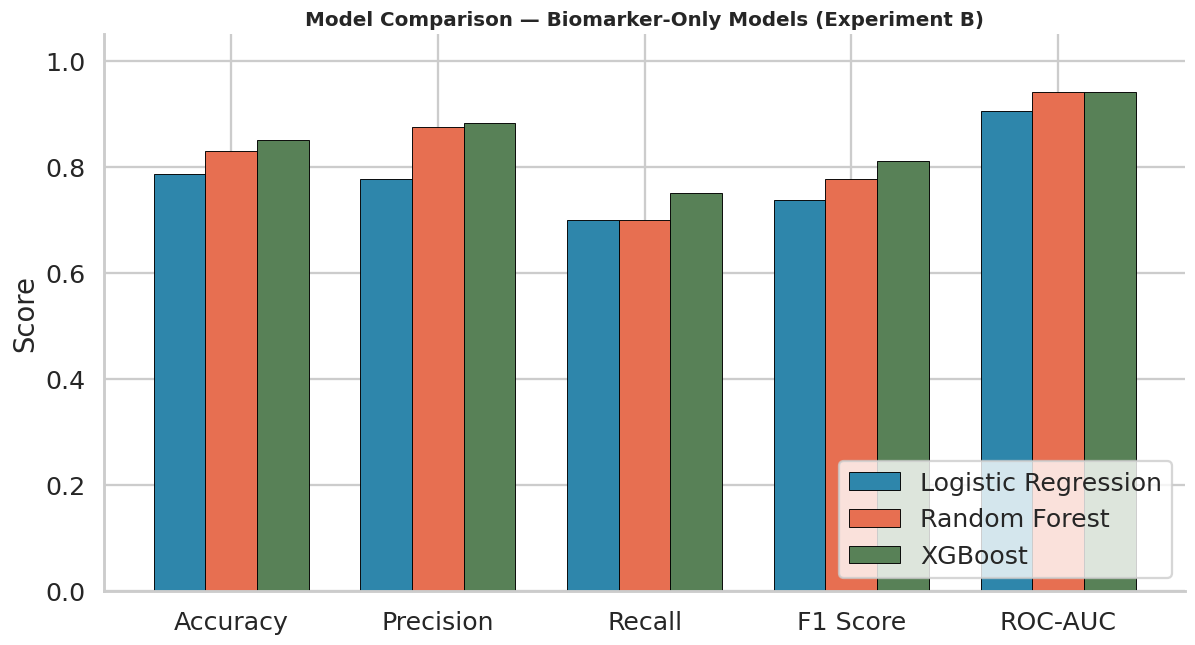

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
x = np.arange(len(metrics))
width = 0.25

for i, (name, _) in enumerate(results_b.items()):
    values = [comparison_b.loc[name, m] for m in metrics]
    ax.bar(x + i * width, values, width, label=name, color=MODEL_COLORS[name], edgecolor="black", linewidth=0.6)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison — Biomarker-Only Models (Experiment B)")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()


**Observation:** This grouped bar chart makes it easy to see whether one model dominates across all metrics or whether there are trade-offs (e.g. higher recall but lower precision). The best-performing model here (by F1/ROC-AUC) will be carried forward as the candidate for the SMOTE rebalancing and SHAP explainability analyses.

In [11]:
best_model_name = comparison_b["F1 Score"].idxmax()
print(f"Best performing model (by F1 Score) on the biomarker-only feature set: {best_model_name}")
print(comparison_b.loc[best_model_name])


Best performing model (by F1 Score) on the biomarker-only feature set: XGBoost
Accuracy     0.851
Precision    0.882
Recall       0.750
F1 Score     0.811
ROC-AUC      0.941
Name: XGBoost, dtype: float64
